# RuleCOSI+ Experimental Grid Search

**Objetivo**: Explorar el espacio de hiperparámetros de RuleCOSI+ sobre el modelo CatBoost preentrenado
para identificar la configuración que minimiza el número de reglas preservando el F1 ≥ 85% del modelo base.

**Hiperparámetros explorados** (n_estimators y tree_max_depth son ignorados por RuleCOSI+ cuando el
base_ensemble ya está entrenado — verificado en código fuente):

| Parámetro | Símbolo | Valores | Efecto |
|-----------|---------|---------|--------|
| `conf_threshold` | α | {0.50, 0.95} | ↑ α → más reglas descartadas |
| `cov_threshold` | β | {0.00, 0.01, 0.10} | ↑ β → más reglas descartadas |
| `c` | c | {0.01, 0.05, 0.10, 0.25} | ↓ c → más poda C4.5 → menos reglas |

**Total**: 2 × 3 × 4 = **24 configuraciones**

**Métricas registradas**: n_rules, F1 en X_test, avg_conditions_per_rule, REDU


In [1]:
import sys
import os
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.metrics import precision_recall_fscore_support

#  Rutas del proyecto 
# El project_root (donde vive config.py) esta 2 niveles arriba
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
vendor_path  = os.path.join(project_root, 'vendor', 'rulecosi')
src_path     = os.path.join(project_root, 'src')

for p in [project_root, vendor_path, src_path]:
    if p not in sys.path:
        sys.path.insert(0, p)

from config import MODEL_DIR, PKL_DIR
from rulecosi import RuleCOSIClassifier
from src.model.train_model import encode_data_like_training

print(f'project_root : {project_root}')
print(f'vendor_path  : {vendor_path}')
print(f'PKL_DIR      : {PKL_DIR}')
print(f'MODEL_DIR    : {MODEL_DIR}')


project_root : c:\Users\danli\OneDrive\Casa Serrano Hidalgo\Danilo\Tesis Danilo\Tesis\Rule reduction\Tesis Byron\Tesis Danilo\01 FUZZY INFERENCE SYSTEM
vendor_path  : c:\Users\danli\OneDrive\Casa Serrano Hidalgo\Danilo\Tesis Danilo\Tesis\Rule reduction\Tesis Byron\Tesis Danilo\01 FUZZY INFERENCE SYSTEM\vendor\rulecosi
PKL_DIR      : c:\Users\danli\OneDrive\Casa Serrano Hidalgo\Danilo\Tesis Danilo\Tesis\Rule reduction\Tesis Byron\Tesis Danilo\01 FUZZY INFERENCE SYSTEM\object\pkl
MODEL_DIR    : c:\Users\danli\OneDrive\Casa Serrano Hidalgo\Danilo\Tesis Danilo\Tesis\Rule reduction\Tesis Byron\Tesis Danilo\01 FUZZY INFERENCE SYSTEM\object\model


## 1. Carga de datos

> **Anti-leakage**: `X_train_cosi` es la partición del 30% del train que el modelo CatBoost
> **nunca vio** durante su entrenamiento. RuleCOSI+ usa estos datos para extraer y evaluar
> reglas sin que el modelo base haya memorizado esos ejemplos.


In [2]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

X_train_cosi = load_pkl(os.path.join(PKL_DIR, 'X_train_cosi.pkl'))
y_train_cosi = load_pkl(os.path.join(PKL_DIR, 'y_train_cosi.pkl'))
X_test       = load_pkl(os.path.join(PKL_DIR, 'X_test.pkl'))
y_test       = load_pkl(os.path.join(PKL_DIR, 'y_test.pkl'))

print(f'X_train_cosi : {X_train_cosi.shape}  ← usado para entrenar RuleCOSI+')
print(f'y_train_cosi : {y_train_cosi.shape}')
print(f'X_test       : {X_test.shape}  ← reservado para evaluación final')
print(f'y_test       : {y_test.shape}')
print(f'\nBalance de clases en train_cosi:')
print(y_train_cosi.value_counts(normalize=True).round(3))


X_train_cosi : (391338, 12)  ← usado para entrenar RuleCOSI+
y_train_cosi : (391338,)
X_test       : (559054, 12)  ← reservado para evaluación final
y_test       : (559054,)

Balance de clases en train_cosi:
bad_good
0    0.805
1    0.195
Name: proportion, dtype: float64


## 2. Carga del modelo CatBoost preentrenado


In [3]:
from catboost import CatBoostClassifier

# ── Identificar el modelo más reciente ──────────────────────────────────────
model_files = [f for f in os.listdir(MODEL_DIR)
               if f.startswith('catboost_DANI_encoded') and f.endswith('_model.cbm')]
model_files.sort(reverse=True)          # el más reciente primero
latest_prefix = model_files[0].replace('_model.cbm', '')
print(f'Modelo seleccionado: {latest_prefix}')

# ── Cargar modelo ───────────────────────────────────────────────────────────
catboost_model = CatBoostClassifier()
catboost_model.load_model(os.path.join(MODEL_DIR, f'{latest_prefix}_model.cbm'))

# ── Cargar cat_mappings ─────────────────────────────────────────────────────
with open(os.path.join(MODEL_DIR, f'{latest_prefix}_category_mappings.pkl'), 'rb') as f:
    cat_mappings = pickle.load(f)

# ── Cargar métricas del modelo base ─────────────────────────────────────────
with open(os.path.join(MODEL_DIR, f'{latest_prefix}_metrics.json'), 'r') as f:
    cb_metrics = json.load(f)

cb_f1        = cb_metrics.get('val_f1',   cb_metrics.get('f1', None))
cb_threshold = cb_metrics.get('optimal_threshold', 0.5)
F1_THRESHOLD = round(cb_f1 * 0.85, 4)   # umbral = 85% del F1 de CatBoost

print(f'\nF1 CatBoost (val)  : {cb_f1:.4f}')
print(f'Umbral aceptable   : {F1_THRESHOLD:.4f}  (85% del F1 base)')
print(f'Threshold óptimo   : {cb_threshold}')


Modelo seleccionado: catboost_DANI_encoded_20260630_194003

F1 CatBoost (val)  : 0.8865
Umbral aceptable   : 0.7536  (85% del F1 base)
Threshold óptimo   : 0.4800000000000001


## 3. Encoding de datos

Se aplican los `cat_mappings` derivados de `X_train_base` para convertir variables
categóricas a numéricas. Esto garantiza que la codificación de `X_train_cosi` y
`X_test` sea consistente con la del modelo base, sin introducir leakage.


In [4]:
X_train_encoded = encode_data_like_training(X_train_cosi, cat_mappings)
X_test_encoded  = encode_data_like_training(X_test, cat_mappings)

print(f'X_train_encoded : {X_train_encoded.shape}')
print(f'X_test_encoded  : {X_test_encoded.shape}')
print(f'\nPrimeras columnas:\n{X_train_encoded.dtypes.head(8)}')


X_train_encoded : (391338, 12)
X_test_encoded  : (559054, 12)

Primeras columnas:
last_fico_range_high    float64
recoveries              float64
term_num                  int64
fico_range_low          float64
total_rec_late_fee      float64
acc_open_past_24mths    float64
dti                     float64
mort_acc                float64
dtype: object


## 4. Reglas baseline (antes de RuleCOSI+)

Se extrae el número total de reglas crispas que CatBoost genera antes de aplicar
ninguna simplificación. Con esto calculare REDU.


In [5]:
# Fit temporal con parámetros permisivos para obtener el conteo baseline
# (sin filtros de alpha/beta, sin poda c agresiva)
rc_baseline = RuleCOSIClassifier(
    base_ensemble=catboost_model,
    conf_threshold=0.0,
    cov_threshold=0.0,
    c=0.999,              # z ≈ 0 → sin poda
    random_state=42
)
rc_baseline.fit(X_train_encoded, y_train_cosi)

N_RULES_BASELINE = sum(
    len(rs.rules) for rs in rc_baseline.original_rulesets_
)
N_RULES_SIMPLIFIED_BASELINE = len(rc_baseline.simplified_ruleset_.rules)

print(f'Reglas crudas extraídas de CatBoost (original_rulesets_) : {N_RULES_BASELINE}')
print(f'Reglas tras simplificación sin filtros                    : {N_RULES_SIMPLIFIED_BASELINE}')
print(f'\nReferencia paper (Jaramillo et al.): 1,681 reglas crispas')


Reglas crudas extraídas de CatBoost (original_rulesets_) : 3009
Reglas tras simplificación sin filtros                    : 14

Referencia paper (Jaramillo et al.): 1,681 reglas crispas


## 5. Grid experimental


In [6]:
# Grid: α × β × c = 2 × 3 × 4 = 24 configuraciones
# n_estimators y tree_max_depth son ignorados por RuleCOSI+ cuando

param_grid = [
    {
        'conf_threshold': alpha,
        'cov_threshold':  beta,
        'c':              c_val
    }
    for alpha in [0.50, 0.95]
    for beta  in [0.00, 0.01, 0.10]
    for c_val in [0.01, 0.05, 0.10, 0.25]
]

print(f'Total configuraciones: {len(param_grid)}')
pd.DataFrame(param_grid)


Total configuraciones: 24


,conf_threshold,cov_threshold,c
0,0.50,0.00,0.01
1,0.50,0.00,0.05
2,0.50,0.00,0.10
3,0.50,0.00,0.25
4,0.50,0.01,0.01
5,0.50,0.01,0.05
6,0.50,0.01,0.10
7,0.50,0.01,0.25
8,0.50,0.10,0.01
9,0.50,0.10,0.05


## 6. Ejecución del grid

> Cada configuración se ajusta una sola vez sobre `X_train_encoded` / `y_train_cosi`
> y se evalúa sobre `X_test_encoded` / `y_test`. Sin CV puro — el proceso es
> determinístico dado el conjunto de datos fijo.


In [7]:
def evaluar_config(params, catboost_model, X_train, y_train, X_test, y_test,
                   n_rules_baseline, cb_f1, i=None, total=None):
    """Ajusta RuleCOSI+ con `params` y retorna las métricas relevantes."""
    if i is not None:
        print(f'  [{i+1:2d}/{total}] α={params["conf_threshold"]:.2f} '
              f'β={params["cov_threshold"]:.2f} c={params["c"]:.2f} ...', end=' ')

    rc = RuleCOSIClassifier(
        base_ensemble=catboost_model,
        **params,
        random_state=42
    )
    rc.fit(X_train, y_train)

    # ── Métricas de reglas ───────────────────────────────────────────────────
    all_rules    = rc.simplified_ruleset_.rules
    active_rules = [r for r in all_rules if len(r.A) > 0]  # excluye regla default
    n_rules      = len(active_rules)
    avg_cond     = (
        round(sum(len(r.A) for r in active_rules) / len(active_rules), 2)
        if active_rules else 0
    )
    redu = round(1 - n_rules / n_rules_baseline, 4) if n_rules_baseline > 0 else 0

    # ── Métricas de clasificación en test ────────────────────────────────────
    y_pred = rc.predict(X_test)
    _, _, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='binary', zero_division=0
    )
    pct_cb = round(f1 / cb_f1 * 100, 1) if cb_f1 > 0 else 0

    if i is not None:
        print(f'n_rules={n_rules:3d}  F1={f1:.4f}  ({pct_cb}% del Cat Boost)')

    return {
        'conf_threshold':  params['conf_threshold'],
        'cov_threshold':   params['cov_threshold'],
        'c':               params['c'],
        'n_rules':         n_rules,
        'F1_test':         round(f1, 4),
        'pct_catboost_f1': pct_cb,
        'avg_conditions':  avg_cond,
        'REDU':            redu,
        'cumple_umbral':   f1 >= (cb_f1 * 0.85)
    }


print('Iniciando grid search (24 configuraciones)...')
print('─' * 65)

all_results = [
    evaluar_config(
        params        = params,
        catboost_model= catboost_model,
        X_train       = X_train_encoded,
        y_train       = y_train_cosi,
        X_test        = X_test_encoded,
        y_test        = y_test,
        n_rules_baseline = N_RULES_BASELINE,
        cb_f1         = cb_f1,
        i             = i,
        total         = len(param_grid)
    )
    for i, params in enumerate(param_grid)
]

print('─' * 65)
print('Completado.')


Iniciando grid search (24 configuraciones)...
─────────────────────────────────────────────────────────────────
  [ 1/24] α=0.50 β=0.00 c=0.01 ... n_rules= 30  F1=0.8835  (99.7% del CB)
  [ 2/24] α=0.50 β=0.00 c=0.05 ... n_rules= 73  F1=0.8823  (99.5% del CB)
  [ 3/24] α=0.50 β=0.00 c=0.10 ... n_rules= 88  F1=0.8822  (99.5% del CB)
  [ 4/24] α=0.50 β=0.00 c=0.25 ... n_rules= 95  F1=0.8825  (99.5% del CB)
  [ 5/24] α=0.50 β=0.01 c=0.01 ... n_rules=  4  F1=0.8810  (99.4% del CB)
  [ 6/24] α=0.50 β=0.01 c=0.05 ... n_rules=  4  F1=0.8810  (99.4% del CB)
  [ 7/24] α=0.50 β=0.01 c=0.10 ... n_rules=  4  F1=0.8810  (99.4% del CB)
  [ 8/24] α=0.50 β=0.01 c=0.25 ... n_rules=  4  F1=0.8810  (99.4% del CB)
  [ 9/24] α=0.50 β=0.10 c=0.01 ... n_rules=  3  F1=0.8691  (98.0% del CB)
  [10/24] α=0.50 β=0.10 c=0.05 ... n_rules=  3  F1=0.8691  (98.0% del CB)
  [11/24] α=0.50 β=0.10 c=0.10 ... n_rules=  3  F1=0.8691  (98.0% del CB)
  [12/24] α=0.50 β=0.10 c=0.25 ... n_rules=  3  F1=0.8691  (98.0% del CB)


## 7. Tabla de métricas

Ordenada por `n_rules` (menor a mayor). Las filas que cumplen el umbral F1 ≥ 85%
del modelo base están marcadas con ✅.


Umbral F1 mínimo: 0.7536  (85% de F1_CB=0.8865)
Configs que cumplen: 24 / 24



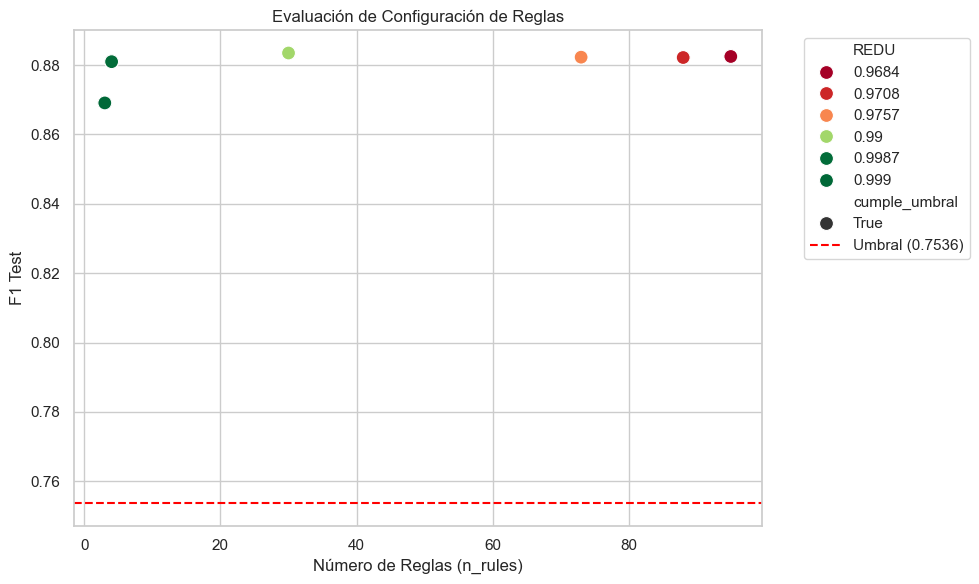

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_results = pd.DataFrame(all_results).sort_values("n_rules").reset_index(drop=True)

# ── Tabla formateada ────────────────────────────────────────────────────────
df_display = df_results.copy()
df_display.index = df_display.index + 1
df_display["cumple_umbral"] = df_display["cumple_umbral"].map(
    {True: "✅", False: "❌"}
)
df_display = df_display.rename(
    columns={
        "conf_threshold": "α",
        "cov_threshold": "β",
        "c": "c",
        "n_rules": "n_reglas",
        "F1_test": "F1_test",
        "pct_catboost_f1": "% F1_CB",
        "avg_conditions": "avg_cond",
        "REDU": "REDU",
        "cumple_umbral": "≥85% CB",
    }
)

print(f"Umbral F1 mínimo: {F1_THRESHOLD:.4f}  (85% de F1_CB={cb_f1:.4f})")
print(
    f"Configs que cumplen: {df_results['cumple_umbral'].sum()} / {len(df_results)}"
)
print()

# ── Visualización con Seaborn (sns) ─────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Grafica n_reglas vs F1_test, usando color para REDU y estilo para el umbral
scatter = sns.scatterplot(
    data=df_results,
    x="n_rules",
    y="F1_test",
    hue="REDU",
    style="cumple_umbral",
    palette="RdYlGn",
    s=100,
)

# Línea de referencia para el umbral mínimo de F1
plt.axhline(
    y=F1_THRESHOLD, color="red", linestyle="--", label=f"Umbral ({F1_THRESHOLD:.4f})"
)

plt.title("Evaluación de Configuración de Reglas")
plt.xlabel("Número de Reglas (n_rules)")
plt.ylabel("F1 Test")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()


## 8. Comparación n_reglas: antes vs. después de RuleCOSI+


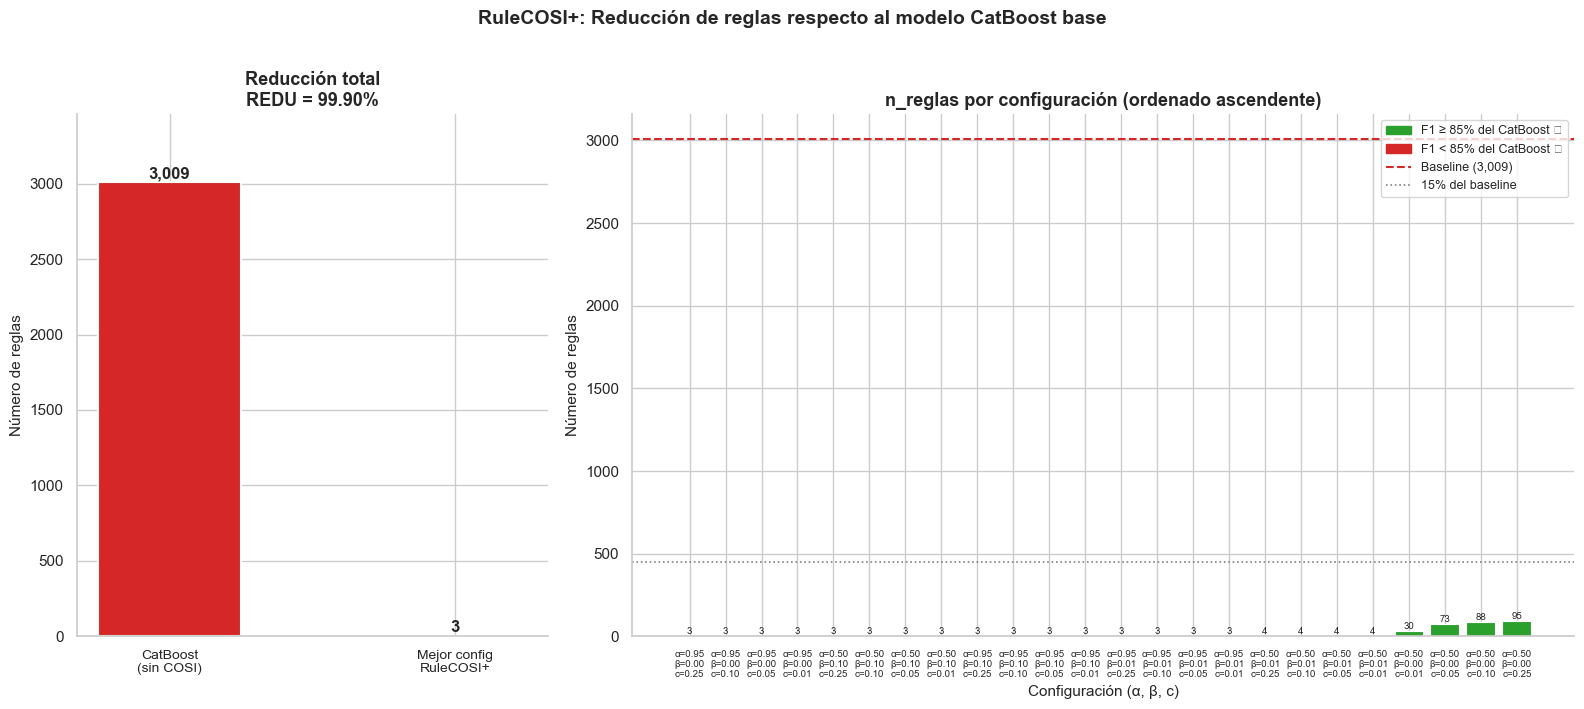

Figura guardada: barras_nreglas_cosi.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 2]})

# ── Panel izquierdo: Baseline vs mejor config ───────────────────────────────
ax0 = axes[0]
best_row = df_results[df_results['cumple_umbral']].nsmallest(1, 'n_rules').iloc[0]
bars0 = ax0.bar(
    ['CatBoost\n(sin COSI)', 'Mejor config\nRuleCOSI+'],
    [N_RULES_BASELINE, best_row['n_rules']],
    color=['#d62728', '#2ca02c'],
    width=0.5, edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars0, [N_RULES_BASELINE, best_row['n_rules']]):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
redu_best = round(1 - best_row['n_rules']/N_RULES_BASELINE, 4)
ax0.set_title(f'Reducción total\nREDU = {redu_best:.2%}', fontsize=13, fontweight='bold')
ax0.set_ylabel('Número de reglas', fontsize=11)
ax0.set_ylim(0, N_RULES_BASELINE * 1.15)
ax0.spines[['top','right']].set_visible(False)
ax0.tick_params(axis='x', labelsize=10)

# ── Panel derecho: todas las 24 configs ────────────────────────────────────
ax1 = axes[1]
df_plot = df_results.sort_values('n_rules').reset_index(drop=True)
labels  = [f"α={r['conf_threshold']:.2f}\nβ={r['cov_threshold']:.2f}\nc={r['c']:.2f}"
           for _, r in df_plot.iterrows()]
colors  = ['#2ca02c' if v else '#d62728' for v in df_plot['cumple_umbral']]

bars1 = ax1.bar(range(len(df_plot)), df_plot['n_rules'],
                color=colors, edgecolor='white', linewidth=0.8)
ax1.axhline(N_RULES_BASELINE, color='#d62728', linestyle='--', linewidth=1.5,
            label=f'Baseline CatBoost ({N_RULES_BASELINE:,} reglas)')
ax1.axhline(N_RULES_BASELINE * 0.15, color='gray', linestyle=':', linewidth=1.2,
            label=f'15% del baseline ({int(N_RULES_BASELINE*0.15)} reglas)')

for bar, val in zip(bars1, df_plot['n_rules']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=7)

ax1.set_xticks(range(len(df_plot)))
ax1.set_xticklabels(labels, fontsize=7)
ax1.set_title('n_reglas por configuración (ordenado ascendente)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Número de reglas', fontsize=11)
ax1.set_xlabel('Configuración (α, β, c)', fontsize=11)
ax1.spines[['top','right']].set_visible(False)

patch_ok  = mpatches.Patch(color='#2ca02c', label='F1 ≥ 85% del CatBoost ✅')
patch_no  = mpatches.Patch(color='#d62728', label='F1 < 85% del CatBoost ❌')
ax1.legend(handles=[patch_ok, patch_no,
                    Line2D([0],[0],color='#d62728',linestyle='--',lw=1.5,label=f'Baseline ({N_RULES_BASELINE:,})'),
                    Line2D([0],[0],color='gray',linestyle=':',lw=1.2,label='15% del baseline')],
           fontsize=9, loc='upper right')

plt.suptitle('RuleCOSI+: Reducción de reglas respecto al modelo CatBoost base',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('barras_nreglas_cosi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: barras_nreglas_cosi.png')


## 9. Heatmap: F1 y n_reglas por configuración


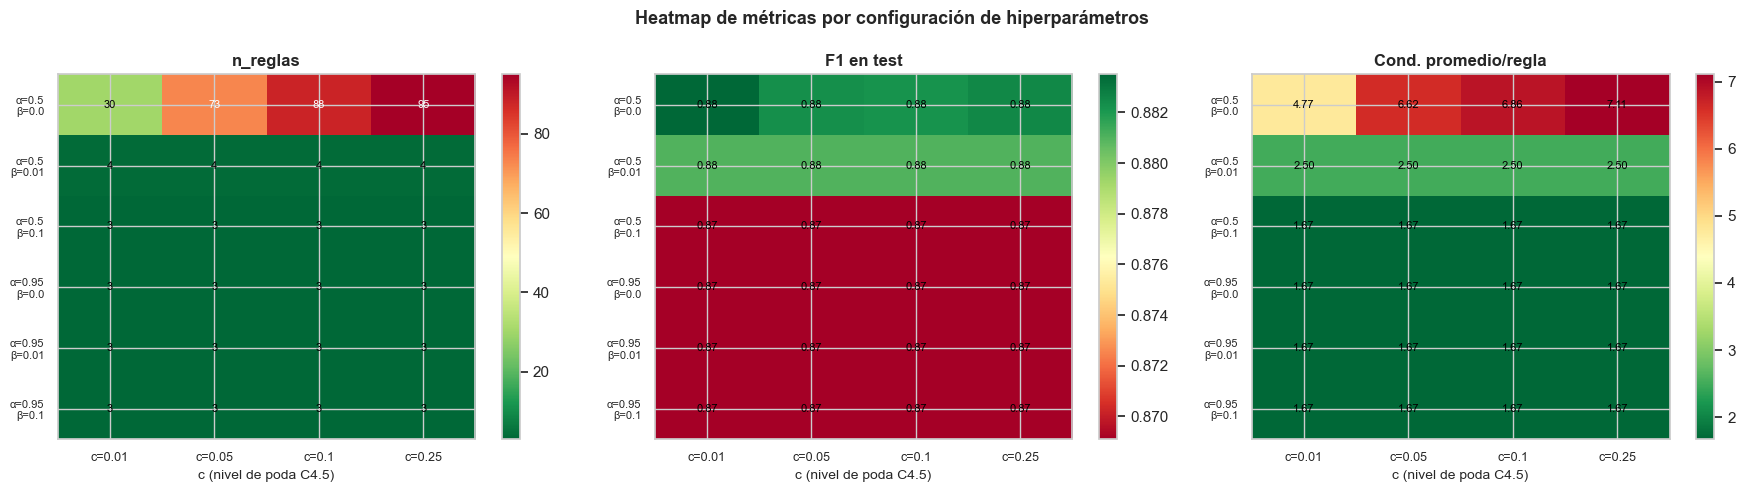

Figura guardada: heatmap_metricas_cosi.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = [
    ('n_rules',        'n_reglas',             'RdYlGn_r', False),
    ('F1_test',        'F1 en test',           'RdYlGn',   False),
    ('avg_conditions', 'Cond. promedio/regla', 'RdYlGn_r', False),
]

for ax, (col, title, cmap, _) in zip(axes, metrics_to_plot):
    pivot = df_results.pivot_table(
        index=['conf_threshold', 'cov_threshold'],
        columns='c',
        values=col,
        aggfunc='first'
    )
    import matplotlib.colors as mcolors
    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'c={v}' for v in pivot.columns], fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'α={a}\nβ={b}' for a,b in pivot.index], fontsize=8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('c (nivel de poda C4.5)', fontsize=10)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            ax.text(j, i, f'{val:.2f}' if isinstance(val, float) else str(val),
                    ha='center', va='center', fontsize=8,
                    color='white' if col == 'n_rules' and val > pivot.values.max()*0.6 else 'black')

plt.suptitle('Heatmap de métricas por configuración de hiperparámetros',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_metricas_cosi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: heatmap_metricas_cosi.png')


## 10. Frontera de Pareto: F1 vs. n_reglas

Un punto es Pareto-óptimo si no existe ninguna otra configuración que simultáneamente
tenga **más F1** y **menos reglas**.


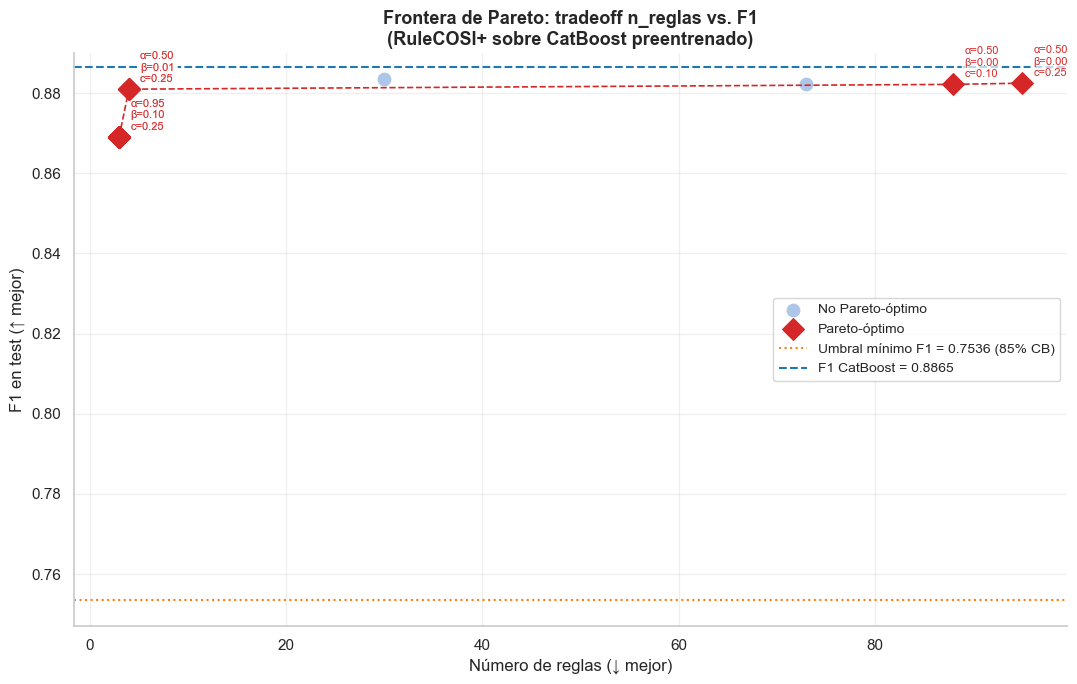

Figura guardada: pareto_cosi_grid.png

Puntos Pareto-óptimos: 22
 conf_threshold  cov_threshold    c  n_rules  F1_test  avg_conditions   REDU
           0.50           0.10 0.01        3   0.8691            1.67 0.9990
           0.50           0.10 0.05        3   0.8691            1.67 0.9990
           0.95           0.00 0.25        3   0.8691            1.67 0.9990
           0.95           0.00 0.10        3   0.8691            1.67 0.9990
           0.95           0.00 0.05        3   0.8691            1.67 0.9990
           0.95           0.00 0.01        3   0.8691            1.67 0.9990
           0.50           0.10 0.25        3   0.8691            1.67 0.9990
           0.50           0.10 0.10        3   0.8691            1.67 0.9990
           0.95           0.01 0.01        3   0.8691            1.67 0.9990
           0.95           0.01 0.05        3   0.8691            1.67 0.9990
           0.95           0.10 0.25        3   0.8691            1.67 0.9990
           

In [13]:
def es_pareto_optimo(costs):
    """Retorna máscara booleana de puntos Pareto-óptimos.
    costs: array de (n_rules, -F1) — minimizamos ambas columnas."""
    is_pareto = np.ones(len(costs), dtype=bool)
    for i, c in enumerate(costs):
        if is_pareto[i]:
            dominated = np.all(costs <= c, axis=1) & np.any(costs < c, axis=1)
            is_pareto[dominated] = False
    return is_pareto

costs    = np.array([[r['n_rules'], -r['F1_test']] for r in all_results])
pareto   = es_pareto_optimo(costs)

fig, ax = plt.subplots(figsize=(11, 7))

# Puntos no-Pareto
ax.scatter(
    [r['n_rules']  for r, p in zip(all_results, pareto) if not p],
    [r['F1_test']  for r, p in zip(all_results, pareto) if not p],
    c='#aec7e8', s=80, zorder=3, label='No Pareto-óptimo'
)

# Puntos Pareto
pareto_pts = [(r['n_rules'], r['F1_test'], r) for r, p in zip(all_results, pareto) if p]
pareto_pts.sort(key=lambda x: x[0])
ax.scatter(
    [p[0] for p in pareto_pts], [p[1] for p in pareto_pts],
    c='#d62728', s=120, zorder=5, marker='D', label='Pareto-óptimo'
)

# Línea Pareto
if pareto_pts:
    ax.plot([p[0] for p in pareto_pts], [p[1] for p in pareto_pts],
            c='#d62728', linestyle='--', linewidth=1.2, zorder=4)

# Etiquetas Pareto
for n_r, f1, r in pareto_pts:
    ax.annotate(
        f"α={r['conf_threshold']:.2f}\nβ={r['cov_threshold']:.2f}\nc={r['c']:.2f}",
        xy=(n_r, f1), xytext=(8, 5), textcoords='offset points',
        fontsize=8, color='#d62728',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7)
    )

# Línea umbral F1
ax.axhline(F1_THRESHOLD, color='#ff7f0e', linestyle=':', linewidth=1.5,
           label=f'Umbral mínimo F1 = {F1_THRESHOLD:.4f} (85% CB)')
ax.axhline(cb_f1, color='#1f77b4', linestyle='--', linewidth=1.5,
           label=f'F1 CatBoost = {cb_f1:.4f}')

ax.set_xlabel('Número de reglas (↓ mejor)', fontsize=12)
ax.set_ylabel('F1 en test (↑ mejor)', fontsize=12)
ax.set_title('Frontera de Pareto: tradeoff n_reglas vs. F1\n(RuleCOSI+ sobre CatBoost preentrenado)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pareto_cosi_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: pareto_cosi_grid.png')

print(f'\nPuntos Pareto-óptimos: {sum(pareto)}')
df_pareto = pd.DataFrame([r for r, p in zip(all_results, pareto) if p])\
              .sort_values('n_rules')
print(df_pareto[['conf_threshold','cov_threshold','c','n_rules','F1_test','avg_conditions','REDU']]\
      .to_string(index=False))


## 11. Selección de la configuración final

Entre los puntos Pareto-óptimos que cumplen el umbral F1 ≥ 85% del modelo base,
se selecciona el que minimiza `n_rules` (máxima interpretabilidad).


In [14]:
candidatos = [r for r, p in zip(all_results, pareto)
              if p and r['cumple_umbral']]

if not candidatos:
    print('⚠️  Ningún punto Pareto-óptimo cumple el umbral F1.')
    print('Relajando criterio — mejor F1 entre todos los Pareto-óptimos:')
    candidatos = [r for r, p in zip(all_results, pareto) if p]

best_config = min(candidatos, key=lambda r: r['n_rules'])

print('=' * 55)
print('  CONFIGURACIÓN SELECCIONADA')
print('=' * 55)
print(f"  conf_threshold (α) : {best_config['conf_threshold']}")
print(f"  cov_threshold  (β) : {best_config['cov_threshold']}")
print(f"  c                  : {best_config['c']}")
print('─' * 55)
print(f"  n_reglas           : {best_config['n_rules']}")
print(f"  F1_test            : {best_config['F1_test']:.4f}")
print(f"  % F1 CatBoost      : {best_config['pct_catboost_f1']}%")
print(f"  avg_conditions     : {best_config['avg_conditions']}")
print(f"  REDU               : {best_config['REDU']:.4f}  "
      f"({best_config['REDU']*100:.1f}% de reglas eliminadas)")
print('=' * 55)

# ── Entrenamiento final con la config seleccionada ──────────────────────────
final_params = {
    'conf_threshold': best_config['conf_threshold'],
    'cov_threshold':  best_config['cov_threshold'],
    'c':              best_config['c']
}

final_rc = RuleCOSIClassifier(
    base_ensemble=catboost_model,
    **final_params,
    random_state=42
)
final_rc.fit(X_train_encoded, y_train_cosi)
print(f'\nModelo final entrenado — reglas: {len([r for r in final_rc.simplified_ruleset_.rules if len(r.A)>0])}')
print('\nReglas del modelo seleccionado:')
print(final_rc.simplified_ruleset_)


  CONFIGURACIÓN SELECCIONADA
  conf_threshold (α) : 0.5
  cov_threshold  (β) : 0.1
  c                  : 0.01
───────────────────────────────────────────────────────
  n_reglas           : 3
  F1_test            : 0.8691
  % F1 CatBoost      : 98.0%
  avg_conditions     : 1.67
  REDU               : 0.9990  (99.9% de reglas eliminadas)

Modelo final entrenado — reglas: 3

Reglas del modelo seleccionado:
r_1: (recoveries ≤ 0.005) ˄ (term_num ≤ 48.000) → [0]
r_2: (recoveries ≤ 0.005) ˄ (last_fico_range_high > 601.500) → [0]
r_3: (recoveries > 0.005) → [1]
r_4:  → [1]



In [15]:
# ── Inspección de las reglas de la mejor configuración ───────────────────
# Primero obtén la config con n_rules=3 y F1=0.8691
rc_inspect = RuleCOSIClassifier(
    base_ensemble=catboost_model,
    conf_threshold=0.50, cov_threshold=0.10, c=0.01,
    random_state=42
)
rc_inspect.fit(X_train_encoded, y_train_cosi)

print("=== Reglas simplificadas ===")
for i, rule in enumerate(rc_inspect.simplified_ruleset_.rules):
    print(f"\nRegla {i}: {'DEFAULT (sin condiciones)' if len(rule.A)==0 else ''}")
    print(f"  Condiciones : {rule.A}")
    print(f"  Clase pred. : {rule.class_index}")
    print(f"  Confianza   : {rule.conf:.4f}")
    print(f"  Cobertura   : {rule.cov:.4f}")

=== Reglas simplificadas ===

Regla 0: 
  Condiciones : frozenset({(-373750500674466870, (recoveries ≤ 0.005)), (4606507218498335520, (term_num ≤ 48.000))})
  Clase pred. : 0
  Confianza   : 0.9518
  Cobertura   : 0.6631

Regla 1: 
  Condiciones : frozenset({(-373750500674466870, (recoveries ≤ 0.005)), (-1502113903452025051, (last_fico_range_high > 601.500))})
  Clase pred. : 0
  Confianza   : 0.9648
  Cobertura   : 0.1698

Regla 2: 
  Condiciones : frozenset({(6465953816512069249, (recoveries > 0.005))})
  Clase pred. : 1
  Confianza   : 1.0000
  Cobertura   : 0.1427

Regla 3: DEFAULT (sin condiciones)
  Condiciones : {}
  Clase pred. : 1
  Confianza   : 0.6063
  Cobertura   : 0.0245
